# Transformers — Arquitectura al Detalle

**Duración estimada:** ~3 horas
**Nivel:** Intermedio / Avanzado
**Requisitos:** PyTorch básico, álgebra lineal, haber visto RNN/LSTM (notebook 03)

En 2017, el paper *"Attention Is All You Need"* (Vaswani et al.) propuso una arquitectura que **eliminó por completo la recurrencia** y sustituyó todo por un mecanismo: **self-attention**. Esa idea —aparentemente simple— es la que hoy está detrás de GPT, BERT, T5, LLaMA, Claude y prácticamente cualquier LLM moderno.

En este notebook construimos un Transformer **desde cero en PyTorch**, módulo por módulo, para entender *por qué funciona* y no solo *qué hace*. Al final:

- implementarás Scaled Dot-Product Attention, Multi-Head Attention, encoding posicional y el bloque Transformer completo;
- entrenarás un Transformer decoder-only (estilo GPT) sobre un corpus pequeño;
- visualizarás los mapas de atención aprendidos;
- entenderás las variantes principales: **encoder-only** (BERT), **decoder-only** (GPT) y **encoder-decoder** (T5, traducción).

> Referencia canónica: Vaswani et al., 2017, *"Attention Is All You Need"* — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762).

---

## Tabla de contenidos

0. [Instalación e imports](#0)
1. [¿Por qué Transformers? El problema con las RNN](#1)
2. [La intuición detrás de *Attention*](#2)
3. [Scaled Dot-Product Attention — el núcleo](#3)
4. [Multi-Head Attention — varias perspectivas a la vez](#4)
5. [Embeddings y codificación posicional](#5)
6. [Feed-Forward, residuales y LayerNorm](#6)
7. [El bloque Transformer completo](#7)
8. [Encoder, Decoder y el Transformer original](#8)
9. [Entrenando un mini-GPT (decoder-only)](#9)
10. [Visualización de atención](#10)
11. [Variantes: BERT, GPT y T5](#11)
12. [Recursos y lecturas](#12)


<a id='0'></a>
---
## 0. Instalación e imports

In [1]:
!uv pip install torch numpy matplotlib requests

Using Python 3.11.13 environment at: /home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv
Audited 4 packages in 2ms


In [2]:
import math
import time
import random
import requests
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch: {torch.__version__}')
print(f'Device : {device}')

PyTorch: 2.11.0+cu130
Device : cuda


<a id='1'></a>
---
## 1. ¿Por qué Transformers? El problema con las RNN

Antes de 2017, el estado del arte en NLP eran las RNN (LSTM, GRU). Tenían **tres problemas estructurales**:

### 1.1 Secuencialidad obligatoria

Una RNN procesa un token, actualiza su estado oculto y recién entonces puede procesar el siguiente:

$$h_t = f(h_{t-1}, x_t)$$

No puedes calcular $h_{100}$ sin haber calculado $h_{99}, h_{98}, \dots, h_1$. Esto impide **paralelizar a lo largo de la secuencia**, así que las RNN no aprovechan bien las GPU modernas.

### 1.2 Cuello de botella del estado oculto

Todo el contexto pasado debe caber en un vector de tamaño fijo $h_t$. Si la secuencia tiene 1000 tokens, los primeros tienen que comprimirse, mezclarse con los siguientes, y aun así quedar recuperables. En la práctica, **la información lejana se diluye**.

### 1.3 Gradientes que se desvanecen

Al hacer backpropagation a través del tiempo (BPTT), el gradiente pasa por $T$ multiplicaciones de matrices. Si los autovalores son $<1$, desaparece; si son $>1$, explota. Las LSTM mitigan esto con las gates, pero no lo eliminan.

### 1.4 La propuesta del Transformer

*¿Y si cada posición pudiera mirar directamente a cualquier otra posición, sin pasar por un estado oculto intermedio?*

Esa es la idea central. El Transformer:

- **Procesa todos los tokens en paralelo** (una matriz, no un bucle).
- Cada token accede **directamente** a cualquier otro vía atención.
- El camino entre dos tokens cualesquiera es de longitud **constante** (no $O(T)$), lo que ayuda al gradiente.

Lo único que se pierde es la noción natural de orden — y la resolveremos con **codificación posicional** (§5).


<a id='2'></a>
---
## 2. La intuición detrás de *Attention*

Piensa en **attention** como una búsqueda suave en una base de datos:

| Concepto                | En una base de datos        | En attention                           |
|-------------------------|-----------------------------|----------------------------------------|
| Consulta (**Query**)    | Lo que quieres buscar       | Representación del token actual        |
| Llave (**Key**)         | Índice de cada registro     | Representación de cada token candidato |
| Valor (**Value**)       | Contenido del registro      | Información que ese token aporta       |
| Coincidencia            | Exacta (=)                  | Producto punto (similitud)             |
| Resultado               | Un registro                 | **Mezcla ponderada** de todos          |

### 2.1 Ejemplo concreto

Tomemos la frase: *"El gato que perseguía al ratón estaba cansado."*

Cuando procesamos la palabra **"estaba"**, necesitamos saber quién estaba cansado. Semánticamente, es *"gato"*, no *"ratón"*. Attention permite que la representación de *"estaba"* consulte todas las palabras anteriores, calcule cuánto se parece cada una a lo que busca (el sujeto del verbo), y **tome una combinación ponderada** de sus significados.

En una RNN, para saberlo, la información de *"gato"* tuvo que sobrevivir en el estado oculto a través de *"que perseguía al ratón"*. En un Transformer, *"estaba"* la consulta **en un solo paso**.

### 2.2 La fórmula que veremos

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

En las siguientes secciones desmontamos cada pieza de esta ecuación.


<a id='3'></a>
---
## 3. Scaled Dot-Product Attention — el núcleo

### 3.1 Desglose de la fórmula

$$\text{Attention}(Q, K, V) = \underbrace{\text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right)}_{\text{pesos de atención }\alpha} V$$

Paso a paso, si tenemos $T$ tokens con dimensión $d_k$:

| Paso | Operación                        | Shape resultante | Significado                                       |
|------|----------------------------------|------------------|---------------------------------------------------|
| 1    | $Q K^\top$                      | $(T, T)$         | Similitud cruda de cada query con cada key        |
| 2    | $\div \sqrt{d_k}$              | $(T, T)$         | Escalado para estabilizar gradientes              |
| 3    | `softmax` por fila               | $(T, T)$         | Pesos $\alpha_{ij}$ que suman 1 por cada query $i$|
| 4    | $\cdot V$                       | $(T, d_v)$       | Mezcla ponderada de los valores                   |

### 3.2 ¿Por qué dividir por $\sqrt{d_k}$?

Si $Q, K$ tienen entradas con media 0 y varianza 1, el producto punto $q \cdot k$ tiene varianza $d_k$. Sin el escalado, cuando $d_k$ es grande (por ej. 64 o 128), los logits antes del softmax son enormes, el softmax se **satura** (un único 1 y el resto 0) y el gradiente casi desaparece.

Dividir por $\sqrt{d_k}$ devuelve la varianza a 1 y mantiene el softmax "suave".

### 3.3 Enmascarado (mask)

En modelos **causales** (decoder-only, como GPT) un token no puede mirar al futuro — sería trampa durante el entrenamiento de *next-token prediction*. La mask pone $-\infty$ en las posiciones prohibidas antes del softmax, para que su peso sea 0.


In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    '''
    Q, K, V: (batch, n_heads, T, d_k)   — o sin n_heads si es atención simple
    mask   : (T, T) o broadcastable. True/1 = posiciones a ocultar (se ponen a -inf)
    Devuelve: salida y los pesos de atención (para visualizar después)
    '''
    d_k = Q.size(-1)

    # (1) Q · Kᵀ  → scores crudos
    scores = Q @ K.transpose(-2, -1)            # (..., T, T)

    # (2) escalar por √d_k
    scores = scores / math.sqrt(d_k)

    # (3) aplicar mask si existe (útil para decoder causal)
    if mask is not None:
        scores = scores.masked_fill(mask == 1, float('-inf'))

    # (4) softmax sobre la dim de keys (la última)
    attn = F.softmax(scores, dim=-1)             # (..., T, T)

    # (5) combinar con V
    out = attn @ V                               # (..., T, d_v)
    return out, attn

### 3.4 Un ejemplo minúsculo hecho a mano

Vamos a ver qué hace la función sobre 4 tokens con `d_k = 8`. Observa los pesos: cada fila suma 1 (es una distribución).

In [4]:
torch.manual_seed(0)
T, d_k = 4, 8
Q = torch.randn(T, d_k)
K = torch.randn(T, d_k)
V = torch.randn(T, d_k)

out, attn = scaled_dot_product_attention(Q, K, V)
print('Forma de la salida :', out.shape)
print('Forma de los pesos :', attn.shape)
print('\nPesos de atención (cada fila suma 1):')
print(attn.round(decimals=3))
print('\nSuma por fila :', attn.sum(dim=-1))

Forma de la salida : torch.Size([4, 8])
Forma de los pesos : torch.Size([4, 4])

Pesos de atención (cada fila suma 1):
tensor([[0.1210, 0.7410, 0.1060, 0.0320],
        [0.2580, 0.2650, 0.1710, 0.3070],
        [0.3360, 0.0170, 0.1870, 0.4600],
        [0.2030, 0.6230, 0.1020, 0.0710]])

Suma por fila : tensor([1.0000, 1.0000, 1.0000, 1.0000])


### 3.5 Visualicemos una mask causal

Para un decoder, queremos que el token $i$ solo vea los tokens $\le i$. Eso se logra con una matriz triangular superior de 1s (posiciones a ocultar):

Mask causal (1 = oculto):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


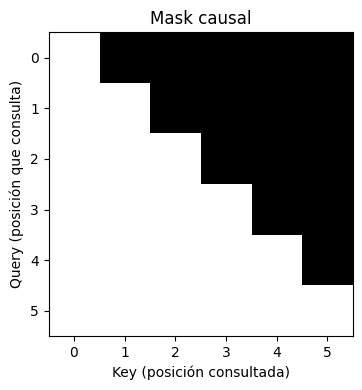

In [5]:
T = 6
causal_mask = torch.triu(torch.ones(T, T), diagonal=1)
print('Mask causal (1 = oculto):')
print(causal_mask.int())

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(causal_mask, cmap='Greys')
ax.set_title('Mask causal')
ax.set_xlabel('Key (posición consultada)')
ax.set_ylabel('Query (posición que consulta)')
plt.tight_layout(); plt.show()

### 3.6 Atención con mask en acción

Aplicamos la misma atención pero esta vez con la mask causal. Fíjate cómo la mitad superior de los pesos se anula:

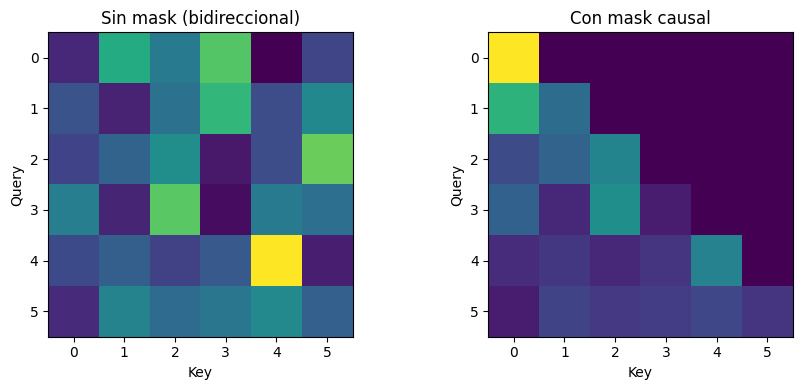

In [6]:
Q = torch.randn(T, d_k)
K = torch.randn(T, d_k)
V = torch.randn(T, d_k)

_, attn_masked = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(torch.softmax(Q @ K.T / math.sqrt(d_k), dim=-1), cmap='viridis')
axes[0].set_title('Sin mask (bidireccional)')
axes[1].imshow(attn_masked, cmap='viridis')
axes[1].set_title('Con mask causal')
for ax in axes:
    ax.set_xlabel('Key'); ax.set_ylabel('Query')
plt.tight_layout(); plt.show()

<a id='4'></a>
---
## 4. Multi-Head Attention — varias perspectivas a la vez

Una sola "cabeza" de atención aprende **un** tipo de relación entre tokens. Pero el lenguaje tiene muchas relaciones simultáneas:

- Un head puede aprender **sintaxis** (sujeto ↔ verbo).
- Otro, **coreferencia** (pronombre ↔ antecedente).
- Otro, **relaciones posicionales** (token anterior).
- Otro, **relaciones semánticas** globales.

La idea de **multi-head** es ejecutar $h$ atenciones en paralelo, cada una proyectando $Q, K, V$ a un subespacio propio:

$$\text{MHA}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) \, W^O$$

$$\text{head}_i = \text{Attention}(X W_i^Q, X W_i^K, X W_i^V)$$

Donde:
- $d_{model}$ es la dimensión del modelo (ej. 512).
- $h$ es el número de heads (ej. 8).
- Cada head trabaja en $d_k = d_v = d_{model} / h$ (ej. 64).

Así, **el costo total es el mismo** que una sola atención grande, pero ahora está repartido en cabezas especializadas.

### 4.1 Implementación

Truco de eficiencia: en lugar de mantener $h$ matrices $W_i^Q$ separadas, usamos **una sola matriz grande** $W^Q \in \mathbb{R}^{d_{model} \times d_{model}}$ y luego **reshape** para separar las cabezas.


In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model debe ser divisible entre n_heads'
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Proyecciones lineales Q, K, V y de salida
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_q, x_k, x_v, mask=None):
        B, T_q, _ = x_q.shape
        T_k = x_k.size(1)

        # 1) proyectar y separar en cabezas: (B, T, d_model) → (B, n_heads, T, d_k)
        def split_heads(x, T):
            return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q = split_heads(self.W_q(x_q), T_q)
        K = split_heads(self.W_k(x_k), T_k)
        V = split_heads(self.W_v(x_v), T_k)

        # 2) atención por head
        out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)
        # out: (B, n_heads, T_q, d_k)

        # 3) concatenar las cabezas: (B, T_q, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T_q, self.d_model)

        # 4) proyección final
        out = self.W_o(out)
        out = self.dropout(out)
        return out, attn

# Sanity check
mha = MultiHeadAttention(d_model=64, n_heads=8)
x = torch.randn(2, 10, 64)          # batch=2, T=10, d_model=64
y, a = mha(x, x, x)                 # self-attention: Q=K=V=x
print(f'Entrada : {tuple(x.shape)}')
print(f'Salida  : {tuple(y.shape)}')
print(f'Attn    : {tuple(a.shape)}   # (B, n_heads, T, T)')

Entrada : (2, 10, 64)
Salida  : (2, 10, 64)
Attn    : (2, 8, 10, 10)   # (B, n_heads, T, T)


### 4.2 Self-attention vs cross-attention

Con el mismo módulo hacemos dos cosas distintas según quién provee $Q, K, V$:

- **Self-attention**: $Q = K = V = x$. Los tokens de una secuencia se miran entre sí.
- **Cross-attention**: $Q$ viene de una secuencia (ej. decoder), $K, V$ de otra (ej. encoder). Se usa en traducción: el decoder "consulta" la oración fuente.


<a id='5'></a>
---
## 5. Embeddings y codificación posicional

### 5.1 Token embeddings

Cada token del vocabulario se convierte en un vector denso de dimensión $d_{model}$. Es la misma `nn.Embedding` de siempre.

### 5.2 El problema del orden

La atención es **permutación-invariante**: si barajas las palabras de una frase, los pesos de atención cambian de posición pero los valores son los mismos. Eso es desastroso: "perro muerde hombre" ≠ "hombre muerde perro".

Necesitamos inyectar información posicional explícitamente.

### 5.3 Encoding posicional sinusoidal (paper original)

Vaswani et al. proponen sumar a cada embedding una señal basada en senos y cosenos de frecuencias variadas:

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**¿Por qué senos/cosenos?**

1. Cada dimensión corresponde a una **longitud de onda distinta**: las primeras dims cambian rápido (codifican orden local), las últimas cambian lento (orden global).
2. Permite **extrapolar a secuencias más largas** que las vistas durante entrenamiento (la función está definida para todo `pos`).
3. $PE_{pos+k}$ se puede expresar como una transformación lineal de $PE_{pos}$ → el modelo puede aprender relaciones relativas fácilmente.

### 5.4 Alternativa: posicionales aprendidos

En lugar de senos/cosenos fijos, `nn.Embedding(max_seq_len, d_model)` aprende los vectores posicionales como parámetros. Es lo que usa GPT. Más flexible, pero no extrapola a longitudes mayores que las vistas en entrenamiento.


In [8]:
class PositionalEncoding(nn.Module):
    '''Codificación posicional sinusoidal (fija, no entrenable).'''
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()              # (max_len, 1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))                   # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)    # dims pares → seno
        pe[:, 1::2] = torch.cos(pos * div)    # dims impares → coseno
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model) — sumamos las primeras T posiciones
        return x + self.pe[:, :x.size(1)]

### 5.5 Visualicemos el encoding

Aquí se ve claramente la estructura: cada fila es una posición, cada columna una dimensión. Las dims bajas oscilan rápido, las altas lento.

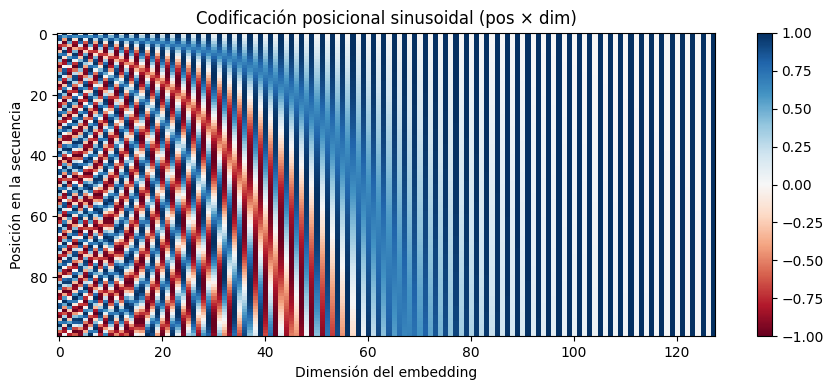

In [9]:
pe_module = PositionalEncoding(d_model=128, max_len=100)
pe = pe_module.pe.squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pe, aspect='auto', cmap='RdBu')
ax.set_xlabel('Dimensión del embedding')
ax.set_ylabel('Posición en la secuencia')
ax.set_title('Codificación posicional sinusoidal (pos × dim)')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

<a id='6'></a>
---
## 6. Feed-Forward, residuales y LayerNorm

La atención mezcla información **entre tokens**, pero cada token sigue necesitando un procesamiento **individual** no lineal. De eso se encargan tres piezas más:

### 6.1 Feed-Forward Network (FFN)

Aplicada de forma **independiente a cada posición**. Típicamente:

$$\text{FFN}(x) = W_2 \, \phi(W_1 x + b_1) + b_2$$

Con $d_{ff} = 4 \cdot d_{model}$ (convención del paper original) y $\phi$ = ReLU o GELU. Es donde **reside la mayor parte de los parámetros** del Transformer.

Intuición: la atención decide *qué información agregar*; la FFN decide *cómo transformarla*.

### 6.2 Conexiones residuales

Cada sub-capa se envuelve como:

$$y = x + \text{SubCapa}(x)$$

Esto permite entrenar redes muy profundas: el gradiente tiene un "atajo" hacia capas tempranas. Sin residuales, Transformers de >10 capas son casi imposibles de entrenar.

### 6.3 LayerNorm

Normaliza cada vector a lo largo de la dimensión `d_model` (no del batch, como BatchNorm):

$$\text{LN}(x) = \gamma \cdot \frac{x - \mu}{\sigma} + \beta$$

Se usa en dos variantes según dónde se coloque:

- **Post-LN** (paper original): `LN(x + SubCapa(x))`.
- **Pre-LN** (GPT-2 en adelante, más estable): `x + SubCapa(LN(x))`.

Aquí usaremos **Pre-LN**, que es el estándar moderno.


In [10]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

<a id='7'></a>
---
## 7. El bloque Transformer completo

Juntamos todo. Un **bloque encoder** (self-attention + FFN, sin mask) y un **bloque decoder** (masked self-attention + cross-attention + FFN).

### 7.1 Bloque encoder (Pre-LN)

```
x ──┬─────────────► LN ──► MHA ──► + ──┬─────► LN ──► FFN ──► + ──► salida
    │                                   │   │                    │
    └───────────────── residual ────────┘   └─── residual ───────┘
```


In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        # Self-attention con residual (Pre-LN)
        a, attn_weights = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), mask=mask)
        x = x + a
        # FFN con residual
        x = x + self.ffn(self.ln2(x))
        return x, attn_weights

### 7.2 Bloque decoder (Pre-LN)

El decoder tiene **tres** sub-capas:

1. **Masked self-attention** — cada posición solo ve el pasado (mask causal).
2. **Cross-attention** — queries del decoder, keys/values del encoder (conecta las dos secuencias).
3. **FFN**.

En un modelo **decoder-only** (GPT), el paso 2 desaparece: solo self-attention enmascarada + FFN.


In [12]:
class DecoderBlock(nn.Module):
    '''Bloque decoder completo: masked self-attn + cross-attn + FFN.'''
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        self.ln2 = nn.LayerNorm(d_model)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)

        self.ln3 = nn.LayerNorm(d_model)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)

    def forward(self, x, enc_out, self_mask=None, cross_mask=None):
        # 1) self-attention enmascarada
        h = self.ln1(x)
        a, self_attn = self.self_attn(h, h, h, mask=self_mask)
        x = x + a
        # 2) cross-attention: Q viene del decoder, K/V del encoder
        h = self.ln2(x)
        a, cross_attn = self.cross_attn(h, enc_out, enc_out, mask=cross_mask)
        x = x + a
        # 3) FFN
        x = x + self.ffn(self.ln3(x))
        return x, self_attn, cross_attn

<a id='8'></a>
---
## 8. Encoder, Decoder y el Transformer original

Apilando $N$ bloques iguales (el paper usa $N = 6$ en cada lado) tenemos los dos "torres":

### 8.1 Arquitectura completa (figura mental)

```
                  Entrada (tokens source)
                         │
                  Embed + PosEnc
                         │
                    ┌────┴────┐
                    │ Encoder │ × N
                    └────┬────┘
                         │ (memoria)
                         │
        ┌────────────────┴─────────────────┐
        │                                  │
  Entrada (tokens target shift)            │
        │                                  │
   Embed + PosEnc                          │
        │                                  │
   ┌────┴────┐ ← K, V ─────────────────────┘
   │ Decoder │ × N
   └────┬────┘
        │
   Linear → Softmax
        │
    Probabilidades del siguiente token
```

### 8.2 Tres familias de modelos

| Familia          | Arquitectura              | Ejemplo   | Tarea típica                    |
|------------------|---------------------------|-----------|---------------------------------|
| **Encoder-only** | solo encoder, no mask     | BERT      | Clasificación, NER, embeddings  |
| **Decoder-only** | solo decoder, mask causal | GPT, LLaMA| Generación de texto             |
| **Encoder-Decoder** | ambos, con cross-attn  | T5, BART, traducción original | Seq2seq |

En §9 entrenamos un **decoder-only** porque es el más relevante hoy (todos los LLM modernos son decoder-only).


<a id='9'></a>
---
## 9. Entrenando un mini-GPT (decoder-only)

Vamos a entrenar un Transformer decoder-only al estilo GPT sobre *El Quijote* (igual que el notebook 03, para comparar). Usaremos **tokenización a nivel de carácter** y un vocabulario pequeño.

### 9.1 Descargar y preparar el corpus

In [13]:
import os

URL = 'https://www.gutenberg.org/cache/epub/2000/pg2000.txt'
CACHE = 'quijote.txt'

if not os.path.exists(CACHE):
    print('Descargando Don Quijote…')
    r = requests.get(URL, timeout=30); r.encoding = 'utf-8'
    with open(CACHE, 'w', encoding='utf-8') as f:
        f.write(r.text)

with open(CACHE, 'r', encoding='utf-8') as f:
    raw = f.read()

import re
m_ini = re.search(r'\*\*\*\s*START OF.*?\*\*\*', raw)
m_fin = re.search(r'\*\*\*\s*END OF.*?\*\*\*', raw)
texto = raw[m_ini.end():m_fin.start()] if (m_ini and m_fin) else raw
texto = texto.replace('\r\n', '\n')
texto = re.sub(r'\n{3,}', '\n\n', texto)

# Corpus completo (~2M caracteres)
print(f'Caracteres: {len(texto):,}')
print(texto[:300])

Caracteres: 2,110,333


El ingenioso hidalgo don Quijote de la Mancha

por Miguel de Cervantes Saavedra

El ingenioso hidalgo don Quijote de la Mancha

  
Tasa

  
Testimonio de las erratas

  
El Rey

  
Al Duque de Béjar

  
Prólogo

  
Al libro de don Quijote de la Mancha

Que trata de la condición y ejercicio del fam


In [14]:
# Tokenización a nivel de carácter
chars = sorted(set(texto))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

def encode(s): return [stoi[c] for c in s]
def decode(ids): return ''.join(itos[i] for i in ids)

data = torch.tensor(encode(texto), dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f'Vocab  : {vocab_size}')
print(f'Train  : {len(train_data):,} tokens')
print(f'Val    : {len(val_data):,} tokens')

Vocab  : 92
Train  : 1,899,299 tokens
Val    : 211,034 tokens


In [15]:
# Batching
SEQ_LEN = 256
BATCH_SIZE = 64

def get_batch(split='train'):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(src) - SEQ_LEN - 1, (BATCH_SIZE,))
    x = torch.stack([src[i      : i + SEQ_LEN]     for i in ix])
    y = torch.stack([src[i + 1  : i + SEQ_LEN + 1] for i in ix])  # y = x shiftado
    return x.to(device), y.to(device)

xb, yb = get_batch()
print(f'x: {tuple(xb.shape)}, y: {tuple(yb.shape)}')

x: (64, 256), y: (64, 256)


### 9.2 Armamos el modelo

Un decoder-only es simplemente:

1. Embedding + codificación posicional.
2. $N$ bloques de `(masked self-attn + FFN)` (sin cross-attn).
3. LayerNorm final + cabeza lineal al vocabulario.


In [16]:
class DecoderOnlyBlock(nn.Module):
    '''Bloque estilo GPT: masked self-attention + FFN (sin cross-attention).'''
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)

    def forward(self, x, mask):
        h = self.ln1(x)
        a, attn = self.attn(h, h, h, mask=mask)
        x = x + a
        x = x + self.ffn(self.ln2(x))
        return x, attn


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 d_ff=512, max_len=512, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)   # posicionales aprendidos (estilo GPT)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            DecoderOnlyBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying (opcional, pero estándar en GPT): comparte pesos entre
        # embedding y cabeza de salida — reduce parámetros y suele mejorar.
        self.head.weight = self.tok_emb.weight

        self.max_len = max_len
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)            # (B, T, d_model)
        x = self.drop(x)

        # mask causal (1 donde queremos ocultar)
        mask = torch.triu(torch.ones(T, T, device=idx.device), diagonal=1)

        attn_maps = []
        for block in self.blocks:
            x, attn = block(x, mask)
            attn_maps.append(attn)

        x = self.ln_f(x)
        logits = self.head(x)                                # (B, T, vocab)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   targets.view(-1))
        return logits, loss, attn_maps

    @torch.no_grad()
    def generar(self, prompt, max_new=300, temp=1.0, top_k=None):
        """Generación robusta: aplica top_k ANTES de temperature y usa
        argmax cuando la distribución es demasiado picuda para multinomial en CUDA."""
        self.eval()
        ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
        for _ in range(max_new):
            idx_cond = ids[:, -self.max_len:]           # truncar al contexto max
            logits, _, _ = self(idx_cond)
            logits = logits[:, -1, :]                   # último paso

            # top_k ANTES de temperature, sobre logits crudos
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                v, _ = logits.topk(k)
                logits = logits.masked_fill(logits < v[:, [-1]], float('-inf'))

            # temperatura con piso para evitar overflow (temp = 0 → argmax)
            if temp < 1e-3:
                next_id = logits.argmax(dim=-1, keepdim=True)
            else:
                logits = logits / temp
                probs = F.softmax(logits, dim=-1)
                # Limpieza paranoica: NaN/Inf pueden aparecer con temperaturas bajas
                probs = torch.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
                # Si quedó una fila sin masa, caer a argmax
                if (probs.sum(dim=-1) <= 0).any():
                    next_id = logits.argmax(dim=-1, keepdim=True)
                else:
                    # Muestrear en CPU evita el assert de multinomial CUDA con
                    # distribuciones muy picudas
                    next_id = torch.multinomial(probs.cpu(), 1).to(ids.device)

            ids = torch.cat([ids, next_id], dim=1)
        return decode(ids[0].tolist())

model = MiniGPT(vocab_size=vocab_size, d_model=256, n_heads=8,
                n_layers=6, d_ff=1024, max_len=SEQ_LEN).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros: {n_params:,}')

Parámetros: 4,822,016


### 9.3 Entrenamiento

Pocos pasos — la idea es que el notebook corra en CPU razonable. Con GPU puedes subir `pasos` a ~5000 para mejor calidad.

In [17]:
def entrenar(modelo, pasos=5000, lr_max=3e-4, lr_min=3e-5,
             warmup=200, eval_cada=250):
    """Entrenamiento con warmup lineal + decaimiento coseno."""
    opt = torch.optim.AdamW(modelo.parameters(), lr=lr_max,
                            betas=(0.9, 0.95), weight_decay=0.1)

    def lr_at(step):
        if step < warmup:
            return lr_max * step / warmup
        # coseno desde lr_max hasta lr_min en los pasos restantes
        progress = (step - warmup) / max(1, pasos - warmup)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * progress))

    hist_train, hist_val, its, lrs = [], [], [], []
    t0 = time.time()
    for it in range(1, pasos + 1):
        # actualizar LR
        lr = lr_at(it)
        for g in opt.param_groups:
            g['lr'] = lr

        modelo.train()
        xb, yb = get_batch('train')
        _, loss, _ = modelo(xb, yb)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        opt.step()

        if it % eval_cada == 0 or it == 1:
            modelo.eval()
            with torch.no_grad():
                # promediar val loss sobre varios batches para reducir ruido
                vls = []
                for _ in range(10):
                    xb, yb = get_batch('val')
                    _, vl, _ = modelo(xb, yb)
                    vls.append(vl.item())
                vloss = sum(vls) / len(vls)
            hist_train.append(loss.item())
            hist_val.append(vloss)
            its.append(it); lrs.append(lr)
            dt = time.time() - t0
            eta = dt / it * (pasos - it)
            print(f'[{it:5d}/{pasos}] train={loss.item():.3f}  val={vloss:.3f}'
                  f'  lr={lr:.1e}  ({dt:.0f}s, ETA {eta:.0f}s)')
    return its, hist_train, hist_val, lrs

its, ht, hv, lrs = entrenar(model, pasos=5000, lr_max=3e-4, lr_min=3e-5,
                            warmup=200, eval_cada=250)

[    1/5000] train=4.602  val=4.588  lr=1.5e-06  (1s, ETA 5359s)
[  250/5000] train=2.279  val=2.283  lr=3.0e-04  (49s, ETA 930s)
[  500/5000] train=2.077  val=2.030  lr=3.0e-04  (97s, ETA 873s)
[  750/5000] train=1.840  val=1.783  lr=2.9e-04  (146s, ETA 825s)
[ 1000/5000] train=1.687  val=1.612  lr=2.8e-04  (194s, ETA 775s)
[ 1250/5000] train=1.553  val=1.502  lr=2.7e-04  (242s, ETA 725s)
[ 1500/5000] train=1.464  val=1.431  lr=2.5e-04  (290s, ETA 677s)
[ 1750/5000] train=1.418  val=1.383  lr=2.4e-04  (339s, ETA 629s)
[ 2000/5000] train=1.416  val=1.332  lr=2.2e-04  (387s, ETA 581s)
[ 2250/5000] train=1.338  val=1.318  lr=2.0e-04  (435s, ETA 531s)
[ 2500/5000] train=1.313  val=1.295  lr=1.7e-04  (483s, ETA 483s)
[ 2750/5000] train=1.294  val=1.271  lr=1.5e-04  (530s, ETA 434s)
[ 3000/5000] train=1.257  val=1.261  lr=1.3e-04  (578s, ETA 386s)
[ 3250/5000] train=1.250  val=1.253  lr=1.1e-04  (626s, ETA 337s)
[ 3500/5000] train=1.242  val=1.232  lr=9.0e-05  (674s, ETA 289s)
[ 3750/5000] 

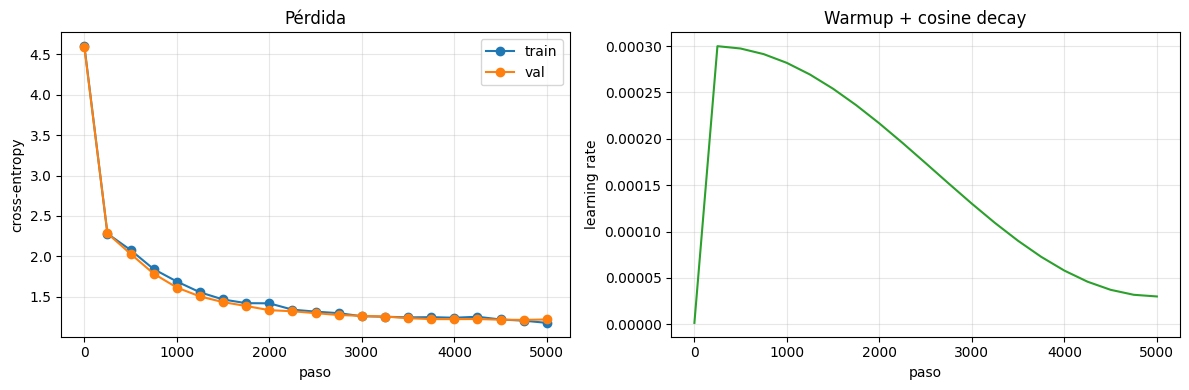

In [18]:
# Curvas de pérdida y schedule de LR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(its, ht, label='train', marker='o')
axes[0].plot(its, hv, label='val',   marker='o')
axes[0].set_xlabel('paso'); axes[0].set_ylabel('cross-entropy')
axes[0].set_title('Pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(its, lrs, color='C2')
axes[1].set_xlabel('paso'); axes[1].set_ylabel('learning rate')
axes[1].set_title('Warmup + cosine decay')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 9.4 Generación

Probamos varias temperaturas. Una temperatura baja hace el muestreo más conservador (más "copia" del corpus); alta, más creativo/errático.

In [21]:
for temp in [0.1,0.6, 0.9, 1.2]:
    print(f'\n========== temperatura {temp} ==========')
    print(model.generar('En un lugar de la Mancha, de', max_new=300, temp=temp, top_k=40))


========== temperatura 0.1 ==========
En un lugar de la Mancha, de quien la cabeza de la cabeza de la
cabeza de la cabeza de la cabeza, y el cual le había dicho en el camino,
de la cual se le dijo:

— Señor mío, que no hay más que no se puede ser que ni es más de la memoria
que no se le ha de decir a la misma parte de la mesma mano que el de la
mano de la Mancha, 

========== temperatura 0.6 ==========
En un lugar de la Mancha, de quien se lleva al pueblo en alguna
mano en el cuerpo, y así como la silla de su amo se conocía el ventero, con
sosisión y arrojó entretenimiento de don Quijote, y le había oído pasado como
la soliza para dicha de don Quijote que le echó su amigo a Anselmo, como
el cura el camino de la Mancha, respo

========== temperatura 0.9 ==========
En un lugar de la Mancha, de una comoquier triste o límita y
cuando llevaba a la honra de su padre; y, a lo cual Roldán. Y
Camila Sancho, comenzaron a una venta y por sus faldas, aunque todas cosas
hasta contigo; la nueva de 

<a id='10'></a>
---
## 10. Visualización de atención

Uno de los encantos del Transformer es que **los pesos de atención son interpretables**. Podemos ver a qué mira cada token.

Extraemos los mapas de atención en una pasada `forward` y graficamos un head por capa.

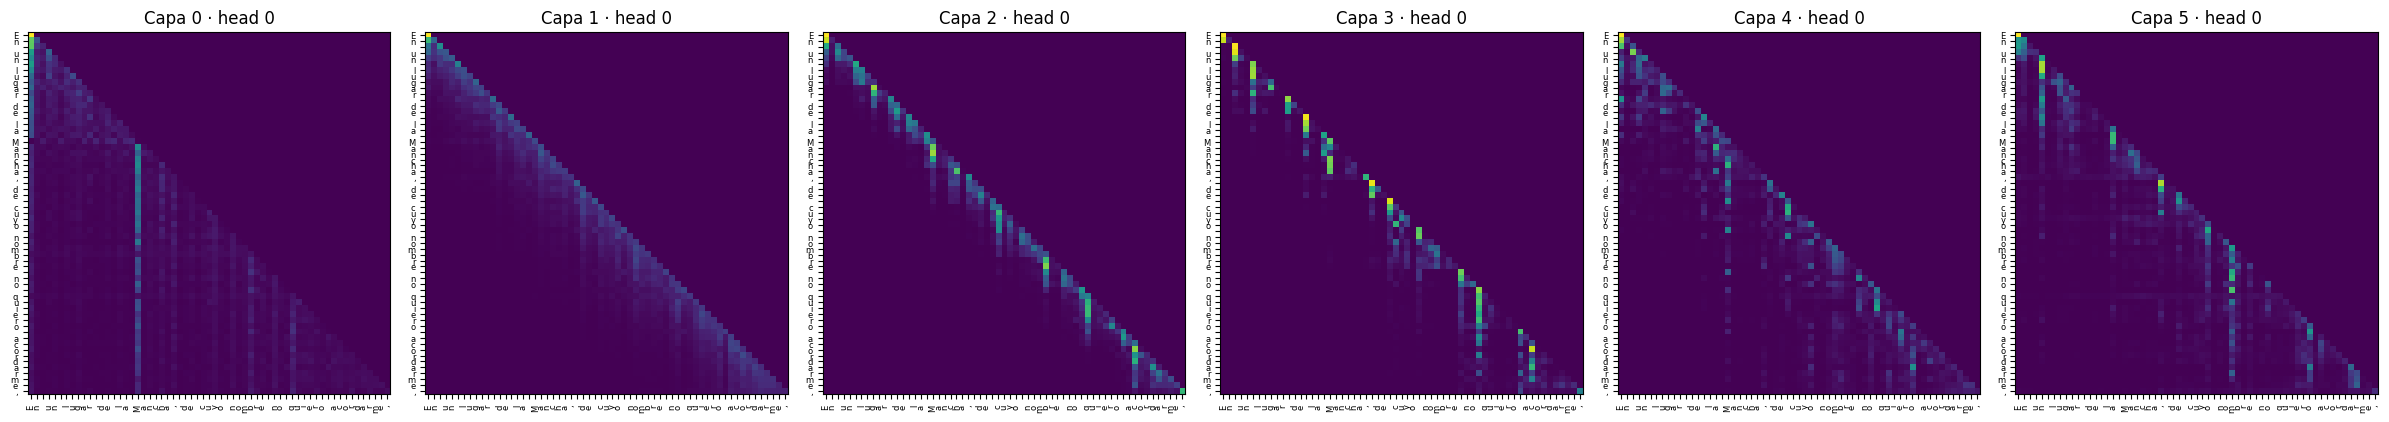

In [20]:
model.eval()
prompt = 'En un lugar de la Mancha, de cuyo nombre no quiero acordarme,'
ids = torch.tensor([encode(prompt)], device=device)
with torch.no_grad():
    _, _, attn_maps = model(ids)

# attn_maps[l] tiene shape (B, n_heads, T, T)
n_layers = len(attn_maps)
T = ids.size(1)
tokens = list(prompt)

fig, axes = plt.subplots(1, n_layers, figsize=(4 * n_layers, 4))
for l, ax in enumerate(axes):
    a = attn_maps[l][0, 0].cpu()                 # head 0 de la capa l
    im = ax.imshow(a, cmap='viridis')
    ax.set_title(f'Capa {l} · head 0')
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, rotation=90, fontsize=6)
    ax.set_yticklabels(tokens, fontsize=6)
plt.tight_layout(); plt.show()

### 10.1 ¿Qué observar?

- En capas bajas los heads suelen atender a **posiciones cercanas** (patrones locales).
- Capas intermedias empiezan a capturar **dependencias de más largo alcance**.
- En modelos grandes se observan heads especializados (heads que detectan comillas, heads sujeto-verbo, etc.). En nuestro mini-GPT apenas se insinúan — con más parámetros y más entrenamiento, los patrones se afinan.
- La **diagonal inferior triangular** siempre está presente por la mask causal.


<a id='11'></a>
---
## 11. Variantes: BERT, GPT y T5

Con los mismos bloques que construimos, entendemos las tres grandes familias que dominaron el NLP moderno:

### 11.1 BERT — *Bidirectional Encoder Representations from Transformers* (2018)

- **Encoder-only**. Sin mask causal: cada token ve todo el contexto (izquierda y derecha).
- **Preentrenamiento**:
  - **Masked Language Modeling (MLM)**: se enmascara el 15% de los tokens, el modelo los predice.
  - **Next Sentence Prediction** (después se abandonó).
- **Uso**: clasificación, NER, embeddings de oraciones. Se le añade una cabeza pequeña y se hace *fine-tuning*.
- **No genera texto bien** — no fue diseñado para eso.

### 11.2 GPT — *Generative Pre-trained Transformer* (2018–hoy)

- **Decoder-only**, self-attention con mask causal.
- **Preentrenamiento**: *next-token prediction* sobre billones de tokens de internet.
- **Uso**: generación, completado, chat, instrucciones. Con suficiente escala emergen comportamientos *zero-shot* y *few-shot*.
- Es la arquitectura de GPT-2/3/4, Claude, LLaMA, Mistral, Qwen… — prácticamente todos los LLM modernos.

### 11.3 T5 — *Text-to-Text Transfer Transformer* (2019)

- **Encoder-decoder completo** (como el paper original).
- **Toda tarea se formula como texto → texto**: traducir, resumir, responder, clasificar… todo es generar una secuencia de texto a partir de otra.
- Muy usado en traducción, resumen, reformulación. BART y mBART son primos cercanos.

### 11.4 Tabla comparativa rápida

| Modelo         | Tipo              | Atención              | Preentrenamiento           | Uso típico        |
|----------------|-------------------|-----------------------|----------------------------|-------------------|
| BERT           | encoder-only      | bidireccional         | MLM                        | Comprensión       |
| GPT            | decoder-only      | causal                | next-token                 | Generación        |
| T5 / BART      | encoder-decoder   | enc bi + dec causal + cross | span-corruption / denoising | Seq2seq       |

### 11.5 ¿Y los modelos modernos?

Todos los LLM de frontera (GPT-4, Claude, Gemini, LLaMA 3, Mistral) siguen siendo **decoder-only** con mejoras incrementales:

- **RoPE** (rotary positional embeddings) en lugar de sinusoidales o aprendidos.
- **RMSNorm** en lugar de LayerNorm.
- **SwiGLU** o **GeGLU** en la FFN en lugar de ReLU/GELU simples.
- **Grouped-Query Attention (GQA)** / **Multi-Query Attention** para ahorrar memoria de KV-cache en inferencia.
- **FlashAttention** para entrenar con contextos largos sin materializar la matriz $T \times T$.

Pero el esqueleto — embeddings, atención enmascarada, FFN, residuales, LayerNorm — es **exactamente el que construimos en este notebook**.


<a id='12'></a>
---
## 12. Recursos y lecturas

### Papers fundamentales
- Vaswani et al. (2017), *Attention Is All You Need* — [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
- Devlin et al. (2018), *BERT* — [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
- Radford et al. (2018/2019), GPT-1 y GPT-2
- Raffel et al. (2019), *T5* — [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)

### Tutoriales muy recomendados
- **The Illustrated Transformer** — Jay Alammar. Intuición visual inmejorable.
- **The Annotated Transformer** — Harvard NLP. El paper línea por línea en PyTorch.
- **Let's build GPT: from scratch, in code, spelled out** — Andrej Karpathy (YouTube + nanoGPT).

### Para seguir (siguiente paso del semillero)
- Afinamiento (fine-tuning) de un LLM preentrenado.
- **RLHF** / **DPO** para alinear.
- **LoRA** y métodos parameter-efficient.
- Cuantización, KV-cache, FlashAttention: el lado sistemas.

---

## Ejercicios sugeridos

1. **Sustituye** la codificación posicional aprendida por la sinusoidal y compara las curvas de pérdida.
2. **Aumenta** `n_layers`, `d_model` y entrenamiento — documenta cómo cambia la calidad.
3. **Entrena un encoder-only** para clasificación de sentimientos (añade un token `[CLS]` y una cabeza MLP).
4. **Implementa KV-cache** en `generar()` para acelerar inferencia (no recalcular K,V de tokens pasados en cada step).
5. **Visualiza los 4 heads** de una capa: ¿se especializan en cosas distintas?
